<a href="https://colab.research.google.com/github/arsalan-jamal002/SMIT-AI-DATA-SCIENCE/blob/main/adult.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [4]:
#Load dataset
df = pd.read_csv('/content/adu.csv')


In [6]:
#print shape,names of columns, info,and first 5 rows.
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
df.info()
print("\nHead:")
print(df.head())

Shape: (48842, 15)

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-wee

In [7]:
# Check unique values or summary statistics for each column, specially looking for '?' or missing values disguised
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"\n--- {col} unique values count ---")
        print(df[col].value_counts().head(10))
    else:
        print(f"\n--- {col} stats ---")
        print(df[col].describe())


--- age stats ---
count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

--- workclass unique values count ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

--- fnlwgt stats ---
count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64

--- education unique values count ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv('adu.csv')

# 2. Standardize missing values ('?' to NaN)
df.replace('?', np.nan, inplace=True)

# 3. Structural overview
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

--- Dataset Shape ---
(48842, 15)

--- Missing Values Check ---
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64


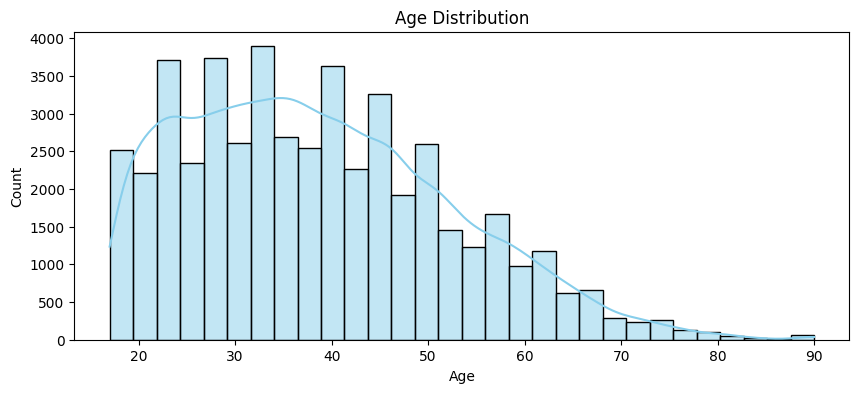

In [10]:
## age (Numerical)
print(df['age'].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

/tmp/ipykernel_3025/2326855876.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='workclass', data=df, order=df['workclass'].value_counts().index, palette='Set2')


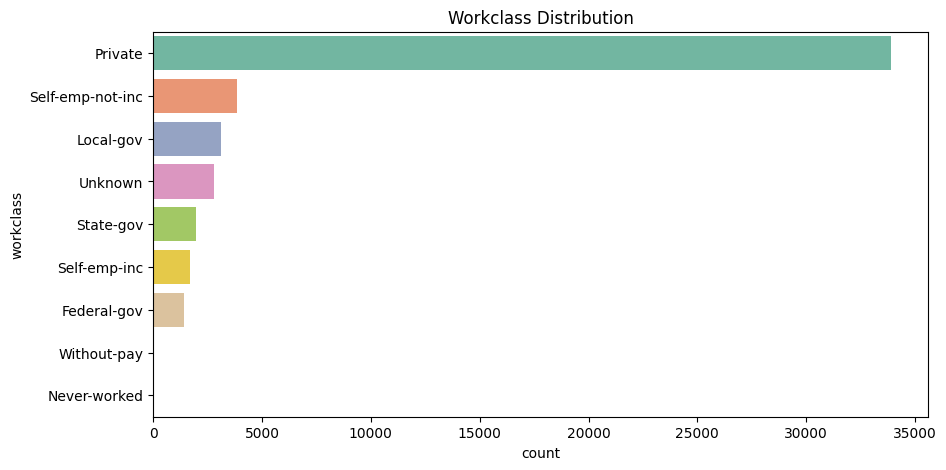

In [12]:
## workclass (Categorical)
# Missing values handle karein
df['workclass'] = df['workclass'].fillna('Unknown')

plt.figure(figsize=(10, 5))
sns.countplot(y='workclass', data=df, order=df['workclass'].value_counts().index, palette='Set2')
plt.title('Workclass Distribution')
plt.show()

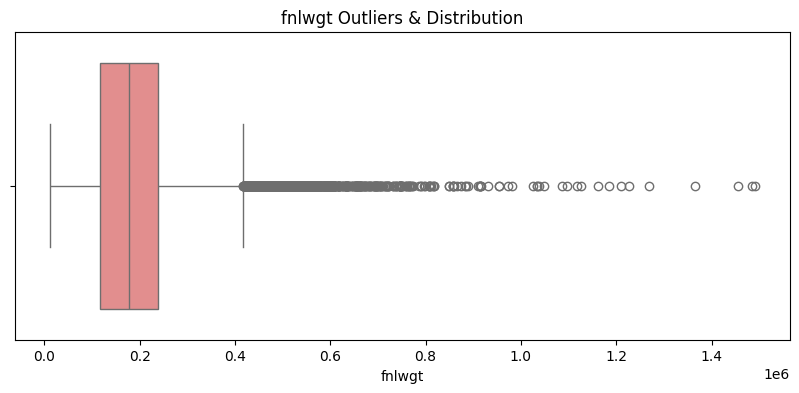

In [13]:
#fnlwgt (Final Weight - Numerical)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['fnlwgt'], color='lightcoral')
plt.title('fnlwgt Outliers & Distribution')
plt.show()

Education Mapping Consistency:
 education
10th             [6]
11th             [7]
12th             [8]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
Assoc-acdm      [12]
Assoc-voc       [11]
Bachelors       [13]
Doctorate       [16]
HS-grad          [9]
Masters         [14]
Preschool        [1]
Prof-school     [15]
Some-college    [10]
Name: educational-num, dtype: object


/tmp/ipykernel_3025/4167625414.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education', data=df, order=df['education'].value_counts().index, palette='viridis')


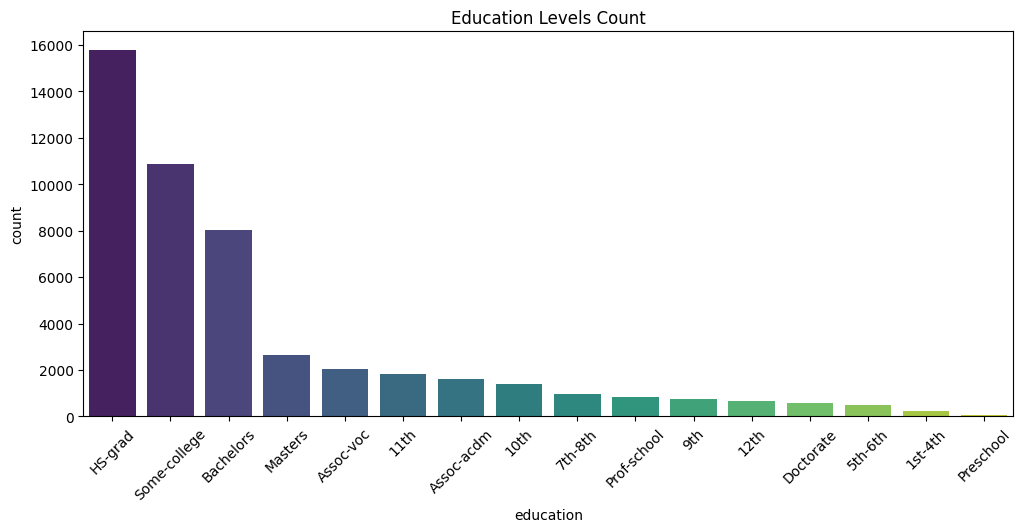

In [14]:
# education & 5. educational-num (Categorical & Numerical)
# Mapping check karein
mapping_check = df.groupby('education')['educational-num'].unique()
print("Education Mapping Consistency:\n", mapping_check)

plt.figure(figsize=(12, 5))
sns.countplot(x='education', data=df, order=df['education'].value_counts().index, palette='viridis')
plt.xticks(rotation=45)
plt.title('Education Levels Count')
plt.show()

/tmp/ipykernel_3025/926411538.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='marital-status', data=df, order=df['marital-status'].value_counts().index, palette='muted')


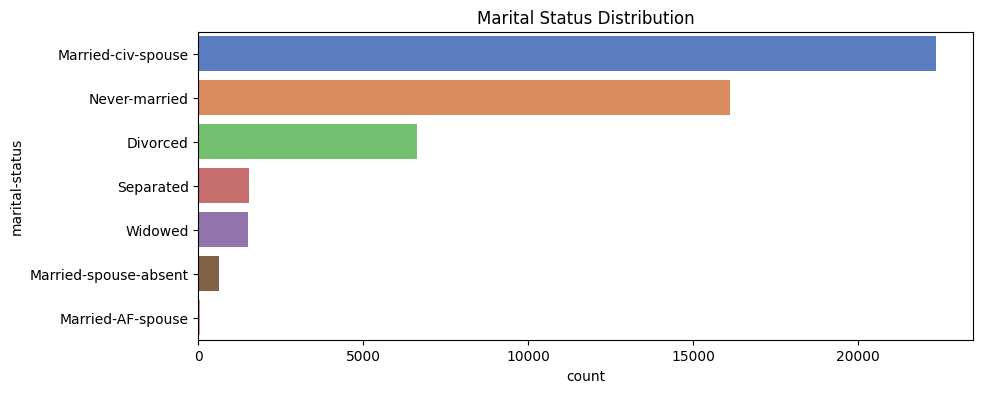

In [15]:
## marital-status (Categorical)
plt.figure(figsize=(10, 4))
sns.countplot(y='marital-status', data=df, order=df['marital-status'].value_counts().index, palette='muted')
plt.title('Marital Status Distribution')
plt.show()

/tmp/ipykernel_3025/3282185077.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='occupation', data=df, order=df['occupation'].value_counts().index, palette='pastel')


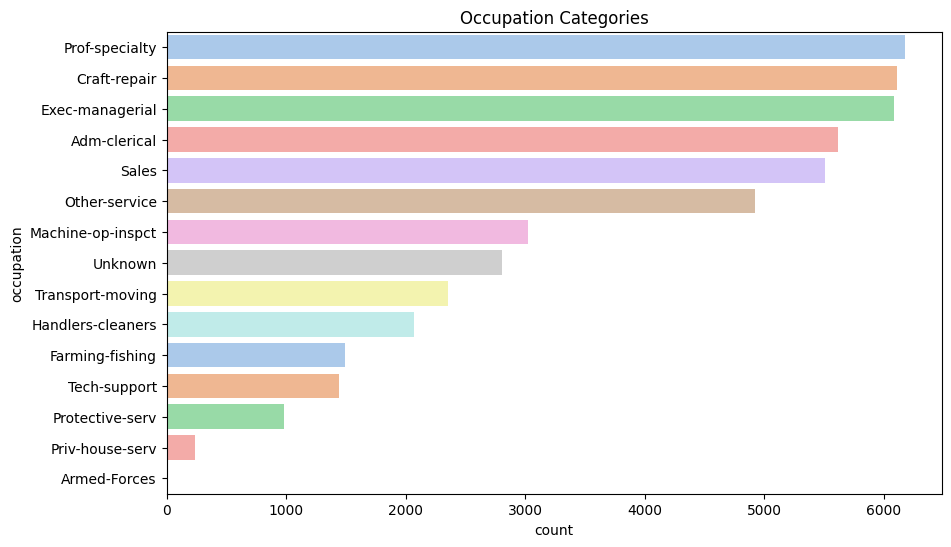

In [16]:
#occupation (Categorical)
df['occupation'] = df['occupation'].fillna('Unknown')

plt.figure(figsize=(10, 6))
sns.countplot(y='occupation', data=df, order=df['occupation'].value_counts().index, palette='pastel')
plt.title('Occupation Categories')
plt.show()

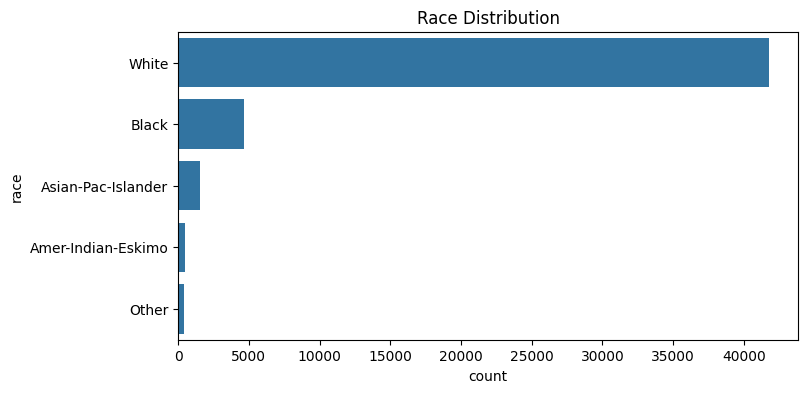

In [17]:
# race (Categorical)
plt.figure(figsize=(8, 4))
sns.countplot(y='race', data=df, order=df['race'].value_counts().index)
plt.title('Race Distribution')
plt.show()

/tmp/ipykernel_3025/1533810168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set1')


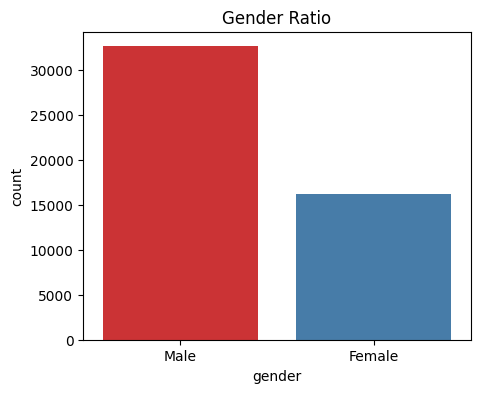

In [18]:
# gender (Categorical)
plt.figure(figsize=(5, 4))
sns.countplot(x='gender', data=df, palette='Set1')
plt.title('Gender Ratio')
plt.show()

Capital Gain non-zero rows: 4035
Capital Loss non-zero rows: 2282


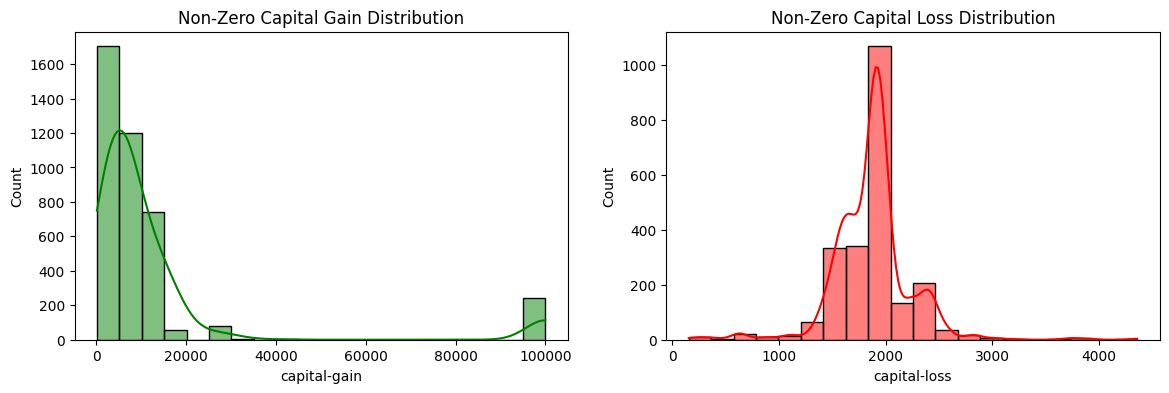

In [19]:
# capital-gain & 12. capital-loss (Numerical)
print("Capital Gain non-zero rows:", (df['capital-gain'] > 0).sum())
print("Capital Loss non-zero rows:", (df['capital-loss'] > 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[df['capital-gain'] > 0]['capital-gain'], bins=20, ax=axes[0], color='green', kde=True)
axes[0].set_title('Non-Zero Capital Gain Distribution')

sns.histplot(df[df['capital-loss'] > 0]['capital-loss'], bins=20, ax=axes[1], color='red', kde=True)
axes[1].set_title('Non-Zero Capital Loss Distribution')
plt.show()

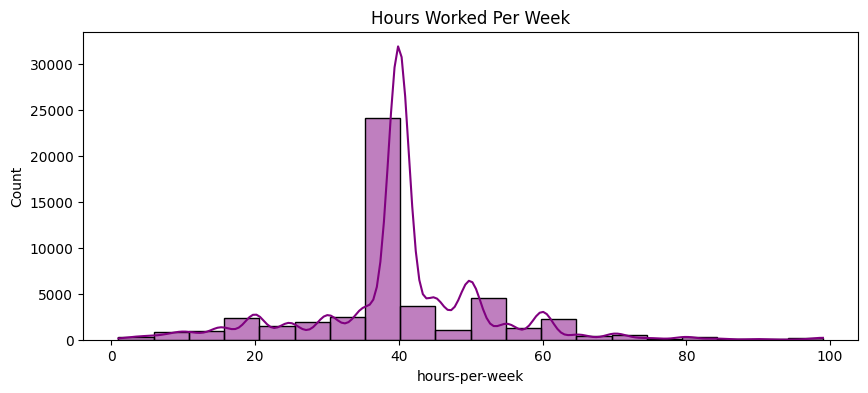

In [20]:
# 13. hours-per-week (Numerical)
plt.figure(figsize=(10, 4))
sns.histplot(df['hours-per-week'], bins=20, kde=True, color='purple')
plt.title('Hours Worked Per Week')
plt.show()

/tmp/ipykernel_3025/3517519695.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


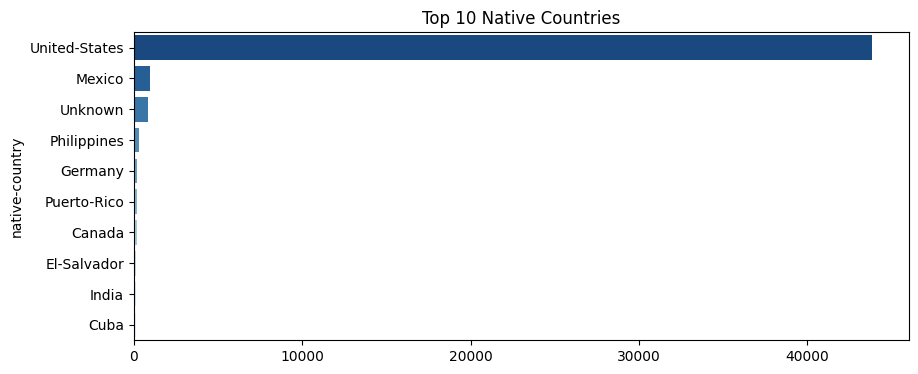

In [21]:
# native-country (Categorical)
df['native-country'] = df['native-country'].fillna('Unknown')

# Top 10 countries show karenge kyunki total categories zyada hain
top_countries = df['native-country'].value_counts().head(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 10 Native Countries')
plt.show()

income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


/tmp/ipykernel_3025/1479636005.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='coolwarm')


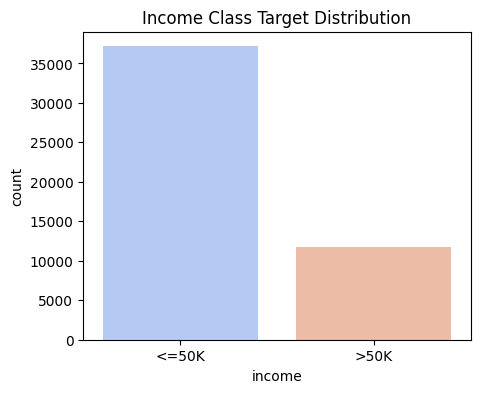

In [22]:
# 15. income (Target Variable - Categorical)
print(df['income'].value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(x='income', data=df, palette='coolwarm')
plt.title('Income Class Target Distribution')
plt.show()

/tmp/ipykernel_3025/891580796.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='age', data=df, ax=axes[0,0], palette='Set3')
/tmp/ipykernel_3025/891580796.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='educational-num', data=df, ax=axes[0,1], palette='Set3')
/tmp/ipykernel_3025/891580796.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='hours-per-week', data=df, ax=axes[1,1], palette='Set3')


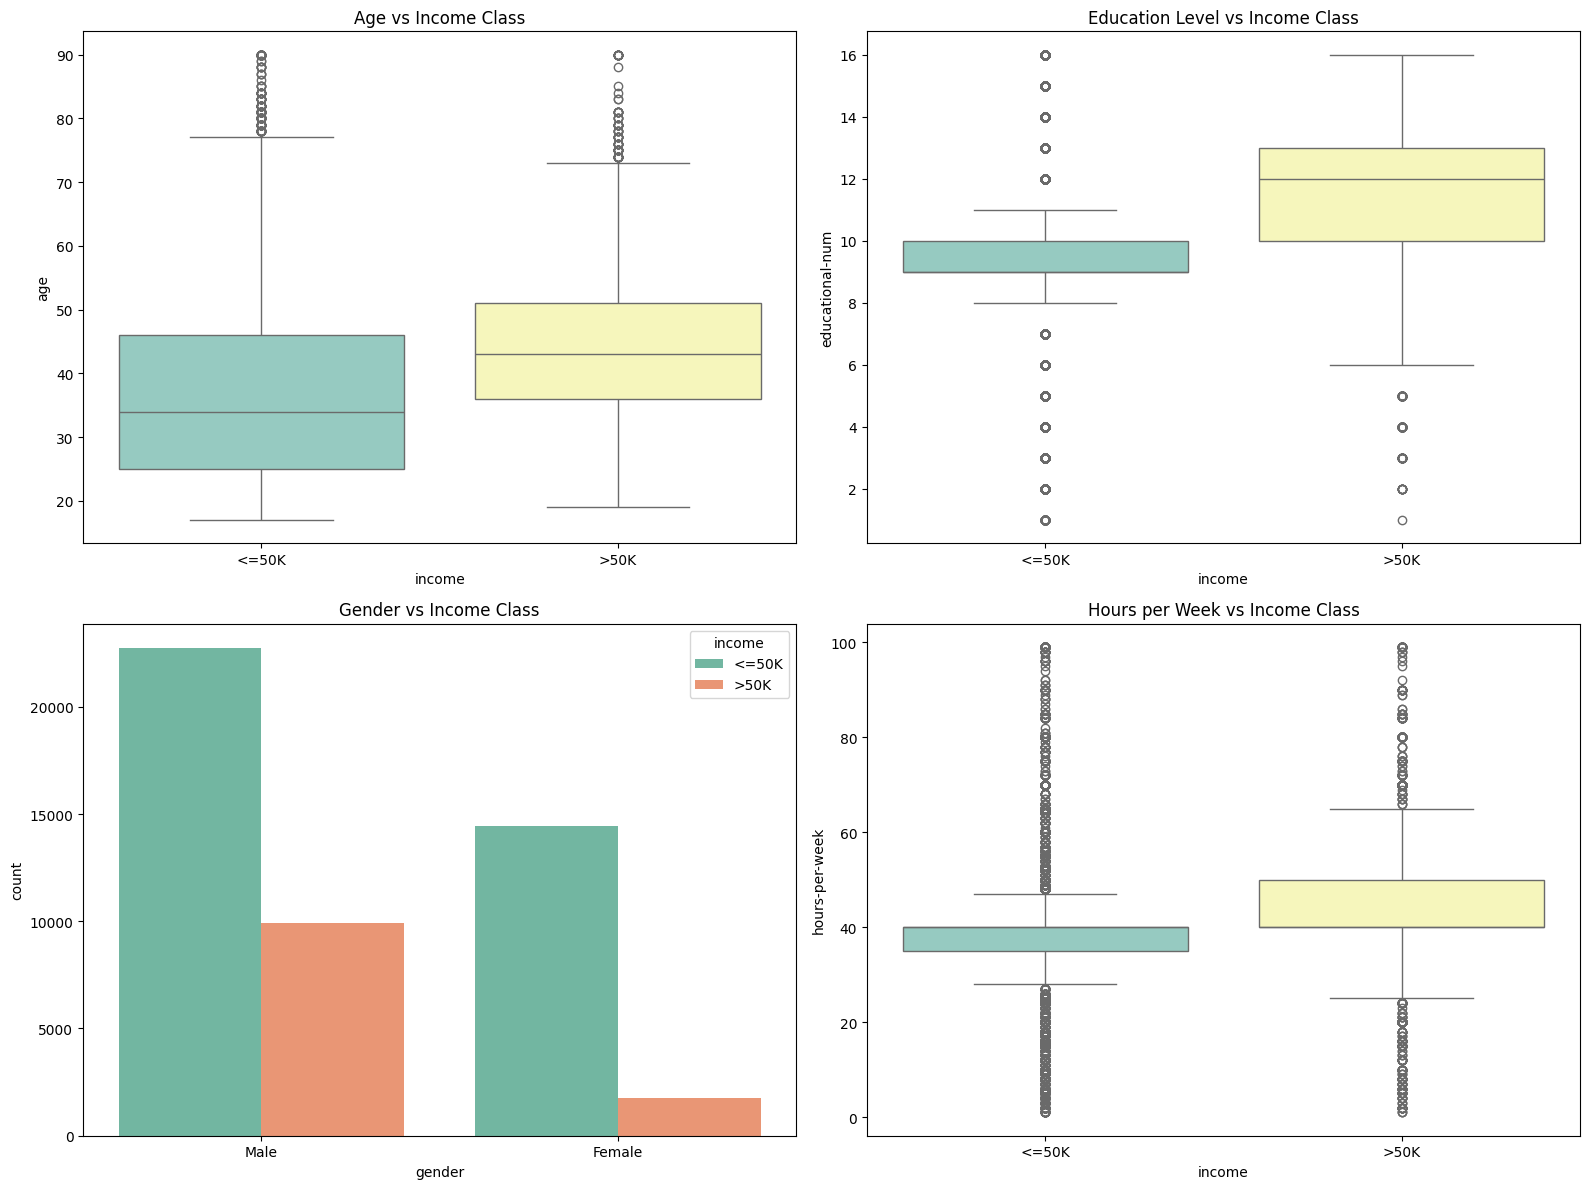

In [23]:
# Step 3: Bi-variate Analysis (Features vs Income Class)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Age vs Income
sns.boxplot(x='income', y='age', data=df, ax=axes[0,0], palette='Set3')
axes[0,0].set_title('Age vs Income Class')

# 2. Education Num vs Income
sns.boxplot(x='income', y='educational-num', data=df, ax=axes[0,1], palette='Set3')
axes[0,1].set_title('Education Level vs Income Class')

# 3. Gender vs Income
sns.countplot(x='gender', hue='income', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Gender vs Income Class')

# 4. Hours worked vs Income
sns.boxplot(x='income', y='hours-per-week', data=df, ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Hours per Week vs Income Class')

plt.tight_layout()
plt.show()

In [24]:
# Step 4: Outliers handling aur Data Duplication check
# Duplicate entries check aur drop karna
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed successfully.")

# Final check to verify dataset clarity
print("\nFinal clean dataset missing values summary:")
print(df.isnull().sum())

Total duplicate rows found: 52
Duplicates removed successfully.

Final clean dataset missing values summary:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [25]:
# Step 5: Cleaned Data Export
df.to_csv('adult_cleaned_dataset.csv', index=False)
print("Adult Dataset fully processed, cleaned and saved!")

Adult Dataset fully processed, cleaned and saved!
